# Utqiagvik **T2m vs. other variables** Analysis 
- All datasets on standard grid
- Bowhead whale hunting relationships between annual mean temperature and other environmental variables
- Notebook by Alice DuVivier (NCAR)
- January 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cmocean
import geopandas as gpd
from metpy.calc import wind_speed
from metpy.calc import wind_direction
from scipy.stats import linregress,pearsonr, t, ttest_ind

## Load Temperature Data

### Load Barrow Observatory Data

In [2]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/NOAA_GML_BRW_MET/'

In [3]:
# years from 1974-2024
years_obs = np.arange(1974,2025,1)
nyrs = len(years_obs)
print(nyrs)

51


In [4]:
# preallocate some arrays
avg_array = np.zeros([nyrs])

# loop through each year to get the data and calculate annual average
for index, yy in enumerate(years_obs):
    file_in = 'brw_met_'+str(yy)+'.csv'
    #print(file_in)
    # load data with pandas
    df = pd.read_csv(dir_in+file_in)
    # read just the temperature values
    temp1 = df['T2m']
    # replace missing values (-999.9) with NaN
    temp2 = temp1.where(temp1> -999.9)
    # calculate annual mean and put this into an array
    avg_array[index] = temp2.mean()

# convert the numpy arrays to xarrays for easier plotting
data_obs = xr.DataArray(avg_array,dims=('years'))
data_obs['years'] = years_obs

In [5]:
# calculate an average temperature for 2000-2020
data_obs_sub = data_obs.where(data_obs.years >= 2000,drop=True)
data_obs_sub = data_obs_sub.where(data_obs_sub.years <= 2020, drop=True)
temp_avg_2000_2020 = data_obs_sub.mean()
temp_std_2000_2020 = data_obs_sub.std()
print(temp_avg_2000_2020)
print(temp_std_2000_2020)

# calculate an average temperature for 2014-2024
data_obs_sub = data_obs.where(data_obs.years >= 2014,drop=True)
temp_avg_2014_2024 = data_obs_sub.mean()
temp_std_2014_2024 = data_obs_sub.std()
print(temp_avg_2014_2024)
print(temp_std_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(1.2872061)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)
<xarray.DataArray ()> Size: 8B
array(1.55803959)


### Load CESM1-LE data

In [6]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [7]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [8]:
temp_cesm1le = ds.TREFHT

### Load CESM2-LE data

In [9]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [10]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [11]:
temp_cesm2le = ds.TREFHT

### Load CESM2-CMIP5 data

In [12]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-TREFHT.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [13]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [14]:
temp_cesm2cmip5 = ds.TREFHT

### Load MESACLIP data
- Load only RCP6.0 data

In [15]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [16]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/1920', end='12/31/2005', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

ds_hist = ds

In [17]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_monthly-TREFHT.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dates = pd.date_range(start='1/1/2006', end='12/31/2104', freq='M')
# check that the # times matches above
#print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

ds_ssp = ds

In [18]:
# concatenate data
ds = xr.concat([ds_hist,ds_ssp],dim='time')

# keep just 9 ensembles
ds = ds.isel(member_id=slice(1,10))

# keep this data
temp_mesaclip_pt = ds.data_pt
temp_mesaclip_small_box = ds.data_small_box
temp_mesaclip = ds.data_big_box

### Get the different numbers of ensembles
- Will need this later

In [19]:
# total ensemble members - will need this later
nens_cesm1le = len(temp_cesm1le.member_id)
print(nens_cesm1le)
nens_cesm2le = len(temp_cesm2le.member_id)
print(nens_cesm2le)
nens_cesm2cmip5 = len(temp_cesm2cmip5.member_id)
print(nens_cesm2cmip5)
nens_mesaclip = len(temp_mesaclip.member_id)
print(nens_mesaclip)

35
50
15
9


## Load SIT Data

### Load CESM1-LE data

In [20]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [21]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [22]:
sit_cesm1le = ds.hi_d

### Load CESM2-LE data

In [23]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [24]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [25]:
sit_cesm2le = ds.hi_d

### Load CESM2-CMIP5 data

In [26]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-hi_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [27]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [28]:
sit_cesm2cmip5 = ds.hi_d

### Load MESACLIP data
- Use only RCP6.0 for future

In [29]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [30]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

ds_hist = ds

(31390,)


In [31]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-hi_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

ds_ssp = ds

(36135,)


In [32]:
# concatenate data - must drop a member from future
ds_ssp = ds_ssp.isel(member_id=slice(1,10))
ds = xr.concat([ds_hist,ds_ssp],dim='time')

# keep this data
sit_mesaclip_pt = ds.data_pt
sit_mesaclip_small_box = ds.data_small_box
sit_mesaclip = ds.data_big_box

## Load SIC Data

### Load CESM1-LE data

In [33]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm1-le_utqiagvik/'
file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [34]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [35]:
sic_cesm1le = ds.aice_d

### Load CESM2-LE data

In [36]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-le_utqiagvik/'
file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [37]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [38]:
sic_cesm2le = ds.aice_d * 100.0

### Load CESM2-CMIP5 data

In [39]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-cmip5_utqiagvik/'
file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-aice_d.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [40]:
# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(66065,)


In [41]:
sic_cesm2cmip5 = ds.aice_d * 100.0

### Load MESACLIP data
- Use only RCP6.0 for future

In [42]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/mesaclip_utqiagvik/'

In [43]:
# historical data
file_in = 'Utqiagvik_MESACLIP_HIST_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1920', end='12/31/2005', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

ds_hist = ds

(31390,)


In [44]:
# rcp6.0 data
file_in = 'Utqiagvik_MESACLIP_RCP6.0_daily-aice_d.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/2006', end='12/31/2104', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

# clip to end at in Dec. 2100
ds = ds.where(ds.time.dt.year <= 2100, drop=True)

ds_ssp = ds

(36135,)


In [45]:
# concatenate data
ds_ssp = ds_ssp.isel(member_id=slice(1,10))
ds = xr.concat([ds_hist,ds_ssp],dim='time')

# keep this data
sic_mesaclip_pt = ds.data_pt
sic_mesaclip_small_box = ds.data_small_box
sic_mesaclip = ds.data_big_box

## Process Annual Mean data
- Timeseries: We need to first calculate the annual mean from daily data. Then from the annual mean temperatures for each ensemble member, we calculate mean and standard deviation. If we use daily data and average across everything then the variance is huge because of the annual cycle.

In [46]:
# years from 1920-2100
years_model = np.arange(1920,2101,1)
nyrs = len(years_model)
print(nyrs)

181


In [47]:
# CESM1-LE
data_model = temp_cesm1le

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm1le])
std_array = np.zeros([nyrs,nens_cesm1le])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### Write variables
cesm1le_avg = model_ens_avg
cesm1le_std = model_ens_std

In [48]:
# CESM2-LE
data_model = temp_cesm2le

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm2le])
std_array = np.zeros([nyrs,nens_cesm2le])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### Write variables
cesm2le_avg = model_ens_avg
cesm2le_std = model_ens_std

In [49]:
# CESM2-CMIP5
data_model = temp_cesm2cmip5

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_cesm2cmip5])
std_array = np.zeros([nyrs,nens_cesm2cmip5])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### Write variables
cesm2cmip5_avg = model_ens_avg
cesm2cmip5_std = model_ens_std

In [50]:
# MESACLIP
# 3 box size options!

### single pt
data_model = temp_mesaclip_pt
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# convert to C from K
data_model = data_model - 273.15
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_pt_avg = model_ens_avg
mesaclip_pt_std = model_ens_std

### small box
data_model = temp_mesaclip_small_box
# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])
# convert to C from K
data_model = data_model - 273.15
# Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')
# Write variables
mesaclip_small_box_avg = model_ens_avg
mesaclip_small_box_std = model_ens_std

### big box
data_model = temp_mesaclip

# preallocate some arrays
avg_array = np.zeros([nyrs,nens_mesaclip])
std_array = np.zeros([nyrs,nens_mesaclip])

# convert to C from K
data_model = data_model - 273.15

### Get annual means from daily data
# loop through each year
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # calculate annual mean
    avg_array[index,:] = temp.mean(dim='time')
# convert the numpy array to xarray
model_avg = xr.DataArray(avg_array,dims=('years','member_id'))
model_avg['years'] = years_model
# Now get the ensemble mean and variance
model_ens_avg = model_avg.mean(dim='member_id')
model_ens_std = model_avg.std(dim='member_id')

### Write variables
mesaclip_avg = model_ens_avg
mesaclip_std = model_ens_std

## Process Spring SIC Frequency
- Timeseries: We need to calculate the annual frequency of times below SIC thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs

SIC thresholds
- Covered:  SIC>=85%
- MIZ:      15%<SIC<85%
- Ice free: SIC<15%

In [51]:
# days are all days in April and May
ndays_spr = 30 + 31

In [52]:
# set thresholds
thresh1 = 85.0
thresh2 = 15.0

In [53]:
# subset to just this season
sic_cesm1le_seas = sic_cesm1le.isel(time=sic_cesm1le.time.dt.month.isin([3,4]))
sic_cesm2le_seas = sic_cesm2le.isel(time=sic_cesm2le.time.dt.month.isin([3,4]))
sic_cesm2cmip5_seas = sic_cesm2cmip5.isel(time=sic_cesm2cmip5.time.dt.month.isin([3,4]))
sic_mesaclip_seas = sic_mesaclip.isel(time=sic_mesaclip.time.dt.month.isin([3,4]))

# single pt data
sic_mesaclip_pt_seas = sic_mesaclip_pt.isel(time=sic_mesaclip_pt.time.dt.month.isin([3,4]))

# small box data
sic_mesaclip_small_box_seas = sic_mesaclip_small_box.isel(time=sic_mesaclip_small_box.time.dt.month.isin([3,4]))


In [54]:
# CESM1-LE
times_tot = ndays_spr*nens_cesm1le
data_model = sic_cesm1le_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_cesm1le = xr.DataArray(array_1,dims=('years'))
sic_thresh1_cesm1le['years'] = years_model
sic_thresh2_cesm1le = xr.DataArray(array_2,dims=('years'))
sic_thresh2_cesm1le['years'] = years_model

In [55]:
# CESM2-LE
times_tot = ndays_spr*nens_cesm2le
data_model = sic_cesm2le_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_cesm2le = xr.DataArray(array_1,dims=('years'))
sic_thresh1_cesm2le['years'] = years_model
sic_thresh2_cesm2le = xr.DataArray(array_2,dims=('years'))
sic_thresh2_cesm2le['years'] = years_model

In [56]:
# CESM2-CMIP5
times_tot = ndays_spr*nens_cesm2cmip5
data_model = sic_cesm2cmip5_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_cesm2cmip5 = xr.DataArray(array_1,dims=('years'))
sic_thresh1_cesm2cmip5['years'] = years_model
sic_thresh2_cesm2cmip5 = xr.DataArray(array_2,dims=('years'))
sic_thresh2_cesm2cmip5['years'] = years_model

In [57]:
# MESACLIP
# 3 box sizes

data_model = sic_mesaclip_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip['years'] = years_model
sic_thresh2_mesaclip = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip['years'] = years_model

### single pt
data_model = sic_mesaclip_pt_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip_pt = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip_pt['years'] = years_model
sic_thresh2_mesaclip_pt = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip_pt['years'] = years_model

### small box
data_model = sic_mesaclip_small_box_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIC<85% conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIC<15% conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sic_thresh1_mesaclip_small_box = xr.DataArray(array_1,dims=('years'))
sic_thresh1_mesaclip_small_box['years'] = years_model
sic_thresh2_mesaclip_small_box = xr.DataArray(array_2,dims=('years'))
sic_thresh2_mesaclip_small_box['years'] = years_model

## Process Spring SIT Frequency
- Timeseries: We need to calculate the annual frequency of times below SIT thresholds for each ensemble member and each year. Thus, total number of points to plot will be nens*nyrs

SIT thresholds
- SIT<1m
- SIT<2m
- Curry and Lopez 2020 say that a minimum of 3-4ft (1m-1.2m) ice thickness is needed for a whale

In [58]:
# days are all days in April and May
ndays_spr = 30 + 31

In [59]:
# set thresholds
thresh1 = 2.0
thresh2 = 1.0

In [60]:
# subset to just this season
sit_cesm1le_seas = sit_cesm1le.isel(time=sit_cesm1le.time.dt.month.isin([3,4]))
sit_cesm2le_seas = sit_cesm2le.isel(time=sit_cesm2le.time.dt.month.isin([3,4]))
sit_cesm2cmip5_seas = sit_cesm2cmip5.isel(time=sit_cesm2cmip5.time.dt.month.isin([3,4]))
sit_mesaclip_seas = sit_mesaclip.isel(time=sit_mesaclip.time.dt.month.isin([3,4]))

# single pt data
sit_mesaclip_pt_seas = sit_mesaclip_pt.isel(time=sit_mesaclip_pt.time.dt.month.isin([3,4]))

# small box data
sit_mesaclip_small_box_seas = sit_mesaclip_small_box.isel(time=sit_mesaclip_small_box.time.dt.month.isin([3,4]))

In [61]:
# CESM1-LE
times_tot = ndays_spr*nens_cesm1le
data_model = sit_cesm1le_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_cesm1le = xr.DataArray(array_1,dims=('years'))
sit_thresh1_cesm1le['years'] = years_model
sit_thresh2_cesm1le = xr.DataArray(array_2,dims=('years'))
sit_thresh2_cesm1le['years'] = years_model

In [62]:
# CESM2-LE
times_tot = ndays_spr*nens_cesm2le
data_model = sit_cesm2le_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    #count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_cesm2le = xr.DataArray(array_1,dims=('years'))
sit_thresh1_cesm2le['years'] = years_model
sit_thresh2_cesm2le = xr.DataArray(array_2,dims=('years'))
sit_thresh2_cesm2le['years'] = years_model

In [63]:
# CESM2-CMIP5
times_tot = ndays_spr*nens_cesm2cmip5
data_model = sit_cesm2cmip5_seas

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_cesm2cmip5 = xr.DataArray(array_1,dims=('years'))
sit_thresh1_cesm2cmip5['years'] = years_model
sit_thresh2_cesm2cmip5 = xr.DataArray(array_2,dims=('years'))
sit_thresh2_cesm2cmip5['years'] = years_model

In [64]:
# MESACLIP
# 3 box sizes

data_model = sit_mesaclip_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip['years'] = years_model
sit_thresh2_mesaclip = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip['years'] = years_model

### single pt
data_model = sit_mesaclip_pt_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip_pt = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip_pt['years'] = years_model
sit_thresh2_mesaclip_pt = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip_pt['years'] = years_model

### small box
data_model = sit_mesaclip_small_box_seas
nens = len(data_model.member_id)
times_tot = ndays_spr*nens

# loop through each year to calculate fractions
array_1 = np.zeros([nyrs])
array_2 = np.zeros([nyrs])

for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d and put into the new array
    temp2 = temp1.stack(all=("member_id","time"))
    temp2 = temp2.compute()
    # count days with SIT<2m conditions
    count = len(temp2.where((temp2 < thresh1),drop=True))
    array_1[index] = 100.0*(count/times_tot)    
    # count days with SIT<1m conditions
    count = len(temp2.where((temp2 < thresh2),drop=True))
    array_2[index] = 100.0*(count/times_tot)

# convert the numpy arrays to xarrays for easier plotting
sit_thresh1_mesaclip_small_box = xr.DataArray(array_1,dims=('years'))
sit_thresh1_mesaclip_small_box['years'] = years_model
sit_thresh2_mesaclip_small_box = xr.DataArray(array_2,dims=('years'))
sit_thresh2_mesaclip_small_box['years'] = years_model

## Calculate linear regressions
- Just the "standard" resolution at this point
- Just for temperatures between -12 and -2C

In [65]:
# set temperature range for regression
tmin = -10 #-12
tmax = -2

# set range for where we'll plot regression
x_reg = np.arange(tmin,tmax+1,1)

### SIC

In [66]:
## CESM2-LE
print('CESM2-LE')
# select data
xdata = cesm2le_avg
ydata = sic_thresh1_cesm2le
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_cesm2le = y_reg
rate_sic_cesm2le = str(round(rate,1))
r2_sic_cesm2le = str(round(r2,2))

CESM2-LE
SIC rate 2.272 %/C; $r^{2}$=0.9


In [67]:
## CESM1-LE
print('CESM1-LE')
# select data
xdata = cesm1le_avg
ydata = sic_thresh1_cesm1le
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_cesm1le = y_reg
rate_sic_cesm1le = str(round(rate,1))
r2_sic_cesm1le = str(round(r2,2))

CESM1-LE
SIC rate 1.766 %/C; $r^{2}$=0.75


In [68]:
## CESM2-CMIP5
print('CESM2-CMIP5')
# select data
xdata = cesm2cmip5_avg
ydata = sic_thresh1_cesm2cmip5
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_cesm2cmip5 = y_reg
rate_sic_cesm2cmip5 = str(round(rate,1))
r2_sic_cesm2cmip5 = str(round(r2,2))

CESM2-CMIP5
SIC rate 1.849 %/C; $r^{2}$=0.73


In [69]:
## MESACLIP
print('MESACLIP')
# select data
xdata = mesaclip_avg
ydata = sic_thresh1_mesaclip
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sic_reg_mesaclip = y_reg
rate_sic_mesaclip = str(round(rate,1))
r2_sic_mesaclip = str(round(r2,2))

MESACLIP
SIC rate 2.057 %/C; $r^{2}$=0.65


### SIT

In [70]:
## CESM2-LE
print('CESM2-LE')
# select data
xdata = cesm2le_avg
ydata = sit_thresh1_cesm2le
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_cesm2le = y_reg
rate_sit_cesm2le = str(round(rate,1))
r2_sit_cesm2le = str(round(r2,2))

CESM2-LE
SIC rate 11.764 %/C; $r^{2}$=0.98


In [71]:
## CESM1-LE
print('CESM1-LE')
# select data
xdata = cesm1le_avg
ydata = sit_thresh1_cesm1le
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_cesm1le = y_reg
rate_sit_cesm1le = str(round(rate,1))
r2_sit_cesm1le = str(round(r2,2))

CESM1-LE
SIC rate 12.592 %/C; $r^{2}$=0.97


In [72]:
## CESM2-CMIP5
print('CESM2-CMIP5')
# select data
xdata = cesm2cmip5_avg
ydata = sit_thresh1_cesm2cmip5
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_cesm2cmip5 = y_reg
rate_sit_cesm2cmip5 = str(round(rate,1))
r2_sit_cesm2cmip5 = str(round(r2,2))

CESM2-CMIP5
SIC rate 11.633 %/C; $r^{2}$=0.94


In [73]:
## MESACLIP
print('MESACLIP')
# select data
xdata = mesaclip_avg
ydata = sit_thresh1_mesaclip
# subset data
mask = xdata.where((xdata >= tmin) & (xdata <= tmax))
xx = xdata.where(mask.notnull(), drop=True)
yy = ydata.where(mask.notnull(), drop=True)
# calculate regression
reg = linregress(xx,yy)
rate = reg.slope
r2 = reg.rvalue*reg.rvalue
y_reg = (reg.slope*x_reg)+reg.intercept
txt = 'SIC rate '+str(round(rate,3))+' %/C; $r^{2}$='+str(round(r2,2))
print(txt)

# get y data to plot
y_sit_reg_mesaclip = y_reg
rate_sit_mesaclip = str(round(rate,1))
r2_sit_mesaclip = str(round(r2,2))

MESACLIP
SIC rate 10.7 %/C; $r^{2}$=0.88


## Plot timeseries and scatter plots

In [74]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_6/'

In [75]:
# calculate an average temperature for 2000-2020
print(temp_avg_2000_2020)

# calculate an average temperature for 2014-2024
print(temp_avg_2014_2024)

<xarray.DataArray ()> Size: 8B
array(-10.09988811)
<xarray.DataArray ()> Size: 8B
array(-9.71130651)


In [76]:
xticks = np.arange(-15,5,5)
xticks

yticks = np.arange(20,60,10)
yticks

array([20, 30, 40, 50])

### All Models on one Plot

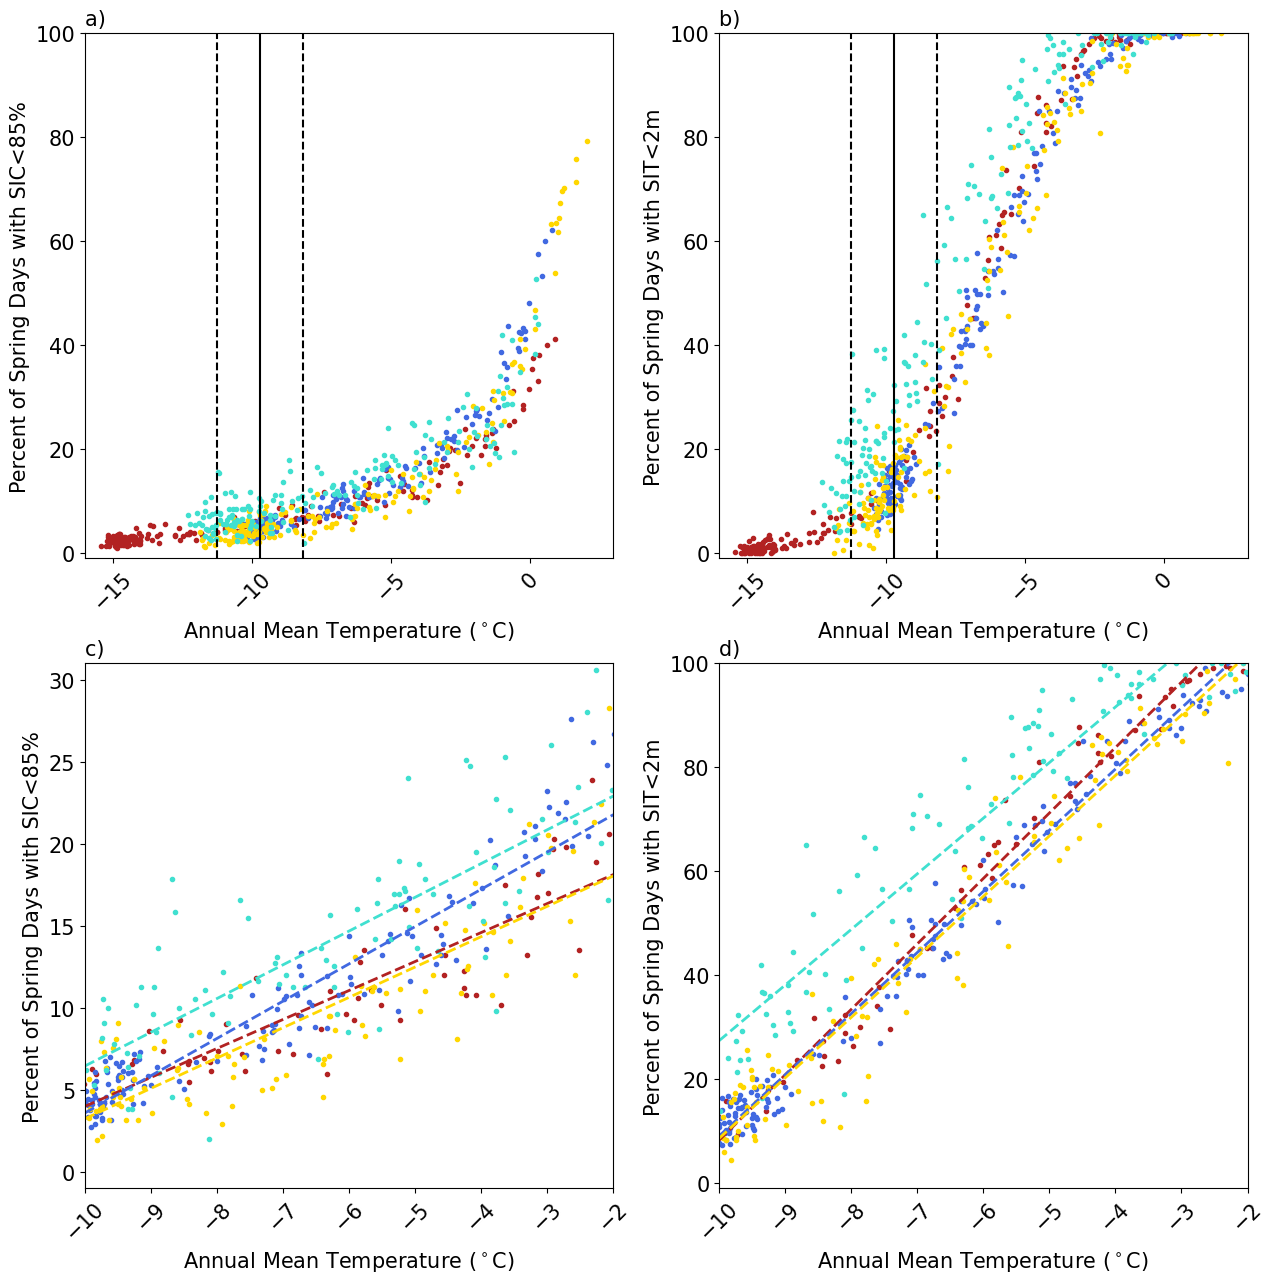

In [84]:
# create figure
fig = plt.figure(figsize=(15,15))
# now loop through months to create subpanels
fout = 'fig_5_utq_temperature_scatter'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### Plot 1 - T2m vs. SIC ###
ax = fig.add_subplot(2,2,1)
# plot data
ax.scatter(cesm1le_avg,sic_thresh1_cesm1le,color="firebrick",marker=".",label='CESM1-LE')
ax.scatter(cesm2le_avg,sic_thresh1_cesm2le,color="royalblue",marker=".",label='CESM2-LE')
ax.scatter(cesm2cmip5_avg,sic_thresh1_cesm2cmip5,color="gold",marker=".",label='CESM2-CMIP5')
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="turquoise",marker=".",label='MESACLIP')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# modify labels and legend
plt.title('a) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-16,3])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - T2m vs. SIT ###
ax = fig.add_subplot(2,2,2)
# set data
ax.scatter(cesm1le_avg,sit_thresh1_cesm1le,color="firebrick",marker=".",label='CESM1-LE')
ax.scatter(cesm2le_avg,sit_thresh1_cesm2le,color="royalblue",marker=".",label='CESM2-LE')
ax.scatter(cesm2cmip5_avg,sit_thresh1_cesm2cmip5,color="gold",marker=".",label='CESM2-CMIP5')
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="turquoise",marker=".",label='MESACLIP')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# modify labels and legend
plt.title('b) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-16,3])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIT<2m',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

############
### Subset and regressions
### Plot 3 - T2m vs. SIC ###
ax = fig.add_subplot(2,2,3)
# plot data
ax.scatter(cesm1le_avg,sic_thresh1_cesm1le,color="firebrick",marker=".")
ax.scatter(cesm2le_avg,sic_thresh1_cesm2le,color="royalblue",marker=".")
ax.scatter(cesm2cmip5_avg,sic_thresh1_cesm2cmip5,color="gold",marker=".")
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="turquoise",marker=".")
# plot regressions
ax.plot(x_reg,y_sic_reg_cesm1le,color='firebrick',linestyle='--',linewidth=2,label='CESM1-LE: slope='+rate_sic_cesm1le+'%/C; r2='+r2_sic_cesm1le)
ax.plot(x_reg,y_sic_reg_cesm2le,color='royalblue',linestyle='--',linewidth=2,label='CESM2-LE: slope='+rate_sic_cesm2le+'%/C; r2='+r2_sic_cesm2le)
ax.plot(x_reg,y_sic_reg_cesm2cmip5,color='gold',linestyle='--',linewidth=2,label='CESM2-CMIP5: slope='+rate_sic_cesm2cmip5+'%/C; r2='+r2_sic_cesm2cmip5)
ax.plot(x_reg,y_sic_reg_mesaclip,color='turquoise',linestyle='--',linewidth=2,label='MESACLIP: slope='+rate_sic_mesaclip+'%/C; r2='+r2_sic_mesaclip)
# modify labels and legend
plt.title('c) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([tmin,tmax])
#ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,31.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 4 - T2m vs. SIT ###
ax = fig.add_subplot(2,2,4)
# set data
ax.scatter(cesm1le_avg,sit_thresh1_cesm1le,color="firebrick",marker=".",label='CESM1-LE')
ax.scatter(cesm2le_avg,sit_thresh1_cesm2le,color="royalblue",marker=".",label='CESM2-LE')
ax.scatter(cesm2cmip5_avg,sit_thresh1_cesm2cmip5,color="gold",marker=".",label='CESM2-CMIP5')
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="turquoise",marker=".",label='MESACLIP')
# plot regressions
ax.plot(x_reg,y_sit_reg_cesm1le,color='firebrick',linestyle='--',linewidth=2,label='CESM1-LE: slope='+rate_sit_cesm1le+'%/C; r2='+r2_sit_cesm1le)
ax.plot(x_reg,y_sit_reg_cesm2le,color='royalblue',linestyle='--',linewidth=2,label='CESM2-LE: slope='+rate_sit_cesm2le+'%/C; r2='+r2_sit_cesm2le)
ax.plot(x_reg,y_sit_reg_cesm2cmip5,color='gold',linestyle='--',linewidth=2,label='CESM2-CMIP5: slope='+rate_sit_cesm2cmip5+'%/C; r2='+r2_sit_cesm2cmip5)
ax.plot(x_reg,y_sit_reg_mesaclip,color='turquoise',linestyle='--',linewidth=2,label='MESACLIP: slope='+rate_sit_mesaclip+'%/C; r2='+r2_sit_mesaclip)
# modify labels and legend
plt.title('d) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([tmin,tmax])
#ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIT<2m',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);
############

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)

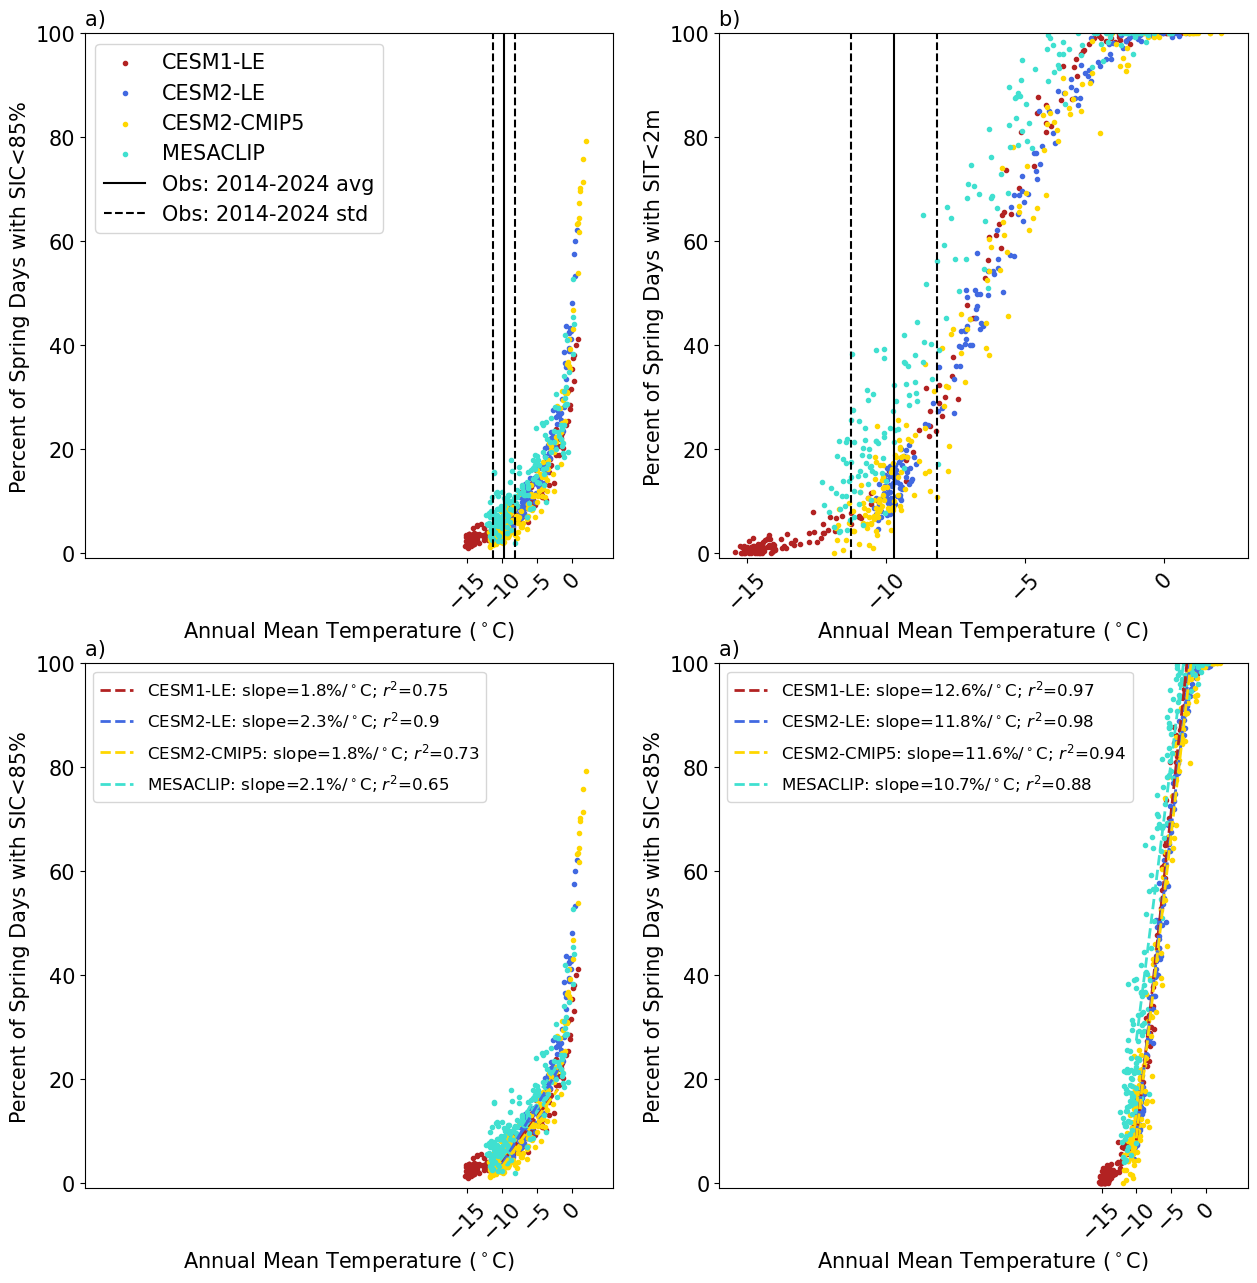

In [85]:
# create figure
fig = plt.figure(figsize=(15,15))
# now loop through months to create subpanels
fout = 'fig_5_legend'

# Make subplot - note it's nrow x ncol x index (starting upper left)
############
### Plot 1 - T2m vs. SIC ###
ax = fig.add_subplot(2,2,1)
# plot data
ax.scatter(cesm1le_avg,sic_thresh1_cesm1le,color="firebrick",marker=".",label='CESM1-LE')
ax.scatter(cesm2le_avg,sic_thresh1_cesm2le,color="royalblue",marker=".",label='CESM2-LE')
ax.scatter(cesm2cmip5_avg,sic_thresh1_cesm2cmip5,color="gold",marker=".",label='CESM2-CMIP5')
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="turquoise",marker=".",label='MESACLIP')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# modify labels and legend
plt.title('a) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-70,6])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
plt.legend(loc='upper left', fontsize=15, ncol=1);

### Plot 2 - T2m vs. SIT ###
ax = fig.add_subplot(2,2,2)
# set data
ax.scatter(cesm1le_avg,sit_thresh1_cesm1le,color="firebrick",marker=".",label='CESM1-LE')
ax.scatter(cesm2le_avg,sit_thresh1_cesm2le,color="royalblue",marker=".",label='CESM2-LE')
ax.scatter(cesm2cmip5_avg,sit_thresh1_cesm2cmip5,color="gold",marker=".",label='CESM2-CMIP5')
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="turquoise",marker=".",label='MESACLIP')
# add line for average of Barrow Observatory for 2014-2024
plt.axvline(x=temp_avg_2014_2024, color='black', linestyle='-',label='Obs: 2014-2024 avg')
plt.axvline(x=temp_avg_2014_2024+temp_std_2014_2024, color='black', linestyle='--',label='Obs: 2014-2024 std')
plt.axvline(x=temp_avg_2014_2024-temp_std_2014_2024, color='black', linestyle='--')
# modify labels and legend
plt.title('b) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-16,3])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIT<2m',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
#plt.legend(loc='upper left', fontsize=15, ncol=1);

############
### Subset and regressions
### Plot 3 - T2m vs. SIC ###
ax = fig.add_subplot(2,2,3)
# plot data
ax.scatter(cesm1le_avg,sic_thresh1_cesm1le,color="firebrick",marker=".")
ax.scatter(cesm2le_avg,sic_thresh1_cesm2le,color="royalblue",marker=".")
ax.scatter(cesm2cmip5_avg,sic_thresh1_cesm2cmip5,color="gold",marker=".")
ax.scatter(mesaclip_avg,sic_thresh1_mesaclip,color="turquoise",marker=".")
# plot regressions
ax.plot(x_reg,y_sic_reg_cesm1le,color='firebrick',linestyle='--',linewidth=2,label='CESM1-LE: slope='+rate_sic_cesm1le+'%/$^\\circ$C; $r^2$='+r2_sic_cesm1le)
ax.plot(x_reg,y_sic_reg_cesm2le,color='royalblue',linestyle='--',linewidth=2,label='CESM2-LE: slope='+rate_sic_cesm2le+'%/$^\\circ$C; $r^2$='+r2_sic_cesm2le)
ax.plot(x_reg,y_sic_reg_cesm2cmip5,color='gold',linestyle='--',linewidth=2,label='CESM2-CMIP5: slope='+rate_sic_cesm2cmip5+'%/$^\\circ$C; $r^2$='+r2_sic_cesm2cmip5)
ax.plot(x_reg,y_sic_reg_mesaclip,color='turquoise',linestyle='--',linewidth=2,label='MESACLIP: slope='+rate_sic_mesaclip+'%/$^\\circ$C; $r^2$='+r2_sic_mesaclip)
# modify labels and legend
plt.title('a) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-70,6])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1);

### Plot 4 - T2m vs. SIT ###
ax = fig.add_subplot(2,2,4)
# set data
ax.scatter(cesm1le_avg,sit_thresh1_cesm1le,color="firebrick",marker=".")
ax.scatter(cesm2le_avg,sit_thresh1_cesm2le,color="royalblue",marker=".")
ax.scatter(cesm2cmip5_avg,sit_thresh1_cesm2cmip5,color="gold",marker=".")
ax.scatter(mesaclip_avg,sit_thresh1_mesaclip,color="turquoise",marker=".")
# plot regressions
ax.plot(x_reg,y_sit_reg_cesm1le,color='firebrick',linestyle='--',linewidth=2,label='CESM1-LE: slope='+rate_sit_cesm1le+'%/$^\\circ$C; $r^2$='+r2_sit_cesm1le)
ax.plot(x_reg,y_sit_reg_cesm2le,color='royalblue',linestyle='--',linewidth=2,label='CESM2-LE: slope='+rate_sit_cesm2le+'%/$^\\circ$C; $r^2$='+r2_sit_cesm2le)
ax.plot(x_reg,y_sit_reg_cesm2cmip5,color='gold',linestyle='--',linewidth=2,label='CESM2-CMIP5: slope='+rate_sit_cesm2cmip5+'%/$^\\circ$C; $r^2$='+r2_sit_cesm2cmip5)
ax.plot(x_reg,y_sit_reg_mesaclip,color='turquoise',linestyle='--',linewidth=2,label='MESACLIP: slope='+rate_sit_mesaclip+'%/$^\\circ$C; $r^2$='+r2_sit_mesaclip)
# modify labels and legend
plt.title('a) ',loc='left',fontsize=15)
plt.xlabel('Annual Mean Temperature ($^\\circ$C)',fontsize=15)
plt.xticks(fontsize=15,rotation=45)
plt.xlim([-70,6])
ax.set_xticks(xticks)
plt.ylabel('Percent of Spring Days with SIC<85%',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([-1,100.0])
#plt.grid()
plt.legend(loc='upper left', fontsize=12, ncol=1);
############

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)